--- Data Loaded Successfully ---
Training data shape: (48048, 7)
Testing data shape: (1001, 7)
Prediction data shape: (1001, 6)


--- Data Preprocessing Complete ---
Features have been scaled.

--- Training the Model ---
Model training complete.

--- Model Evaluation on Test Data ---
R-squared (R²) Score: 1.0000
Mean Absolute Error (MAE): 0.0036
Mean Squared Error (MSE): 0.0000
Root Mean Squared Error (RMSE): 0.0064

--- Making Final Predictions ---
Preview of the predictions:
   Frequency  Ws  H1  D1  Lp  W1  Predicted_S11
0      1.000  10  13   8  20  23      -0.708389
1      1.009  10  13   8  20  23      -0.724073
2      1.018  10  13   8  20  23      -0.747193
3      1.027  10  13   8  20  23      -0.774279
4      1.036  10  13   8  20  23      -0.808596


Predictions saved to 'predictions_output.csv'


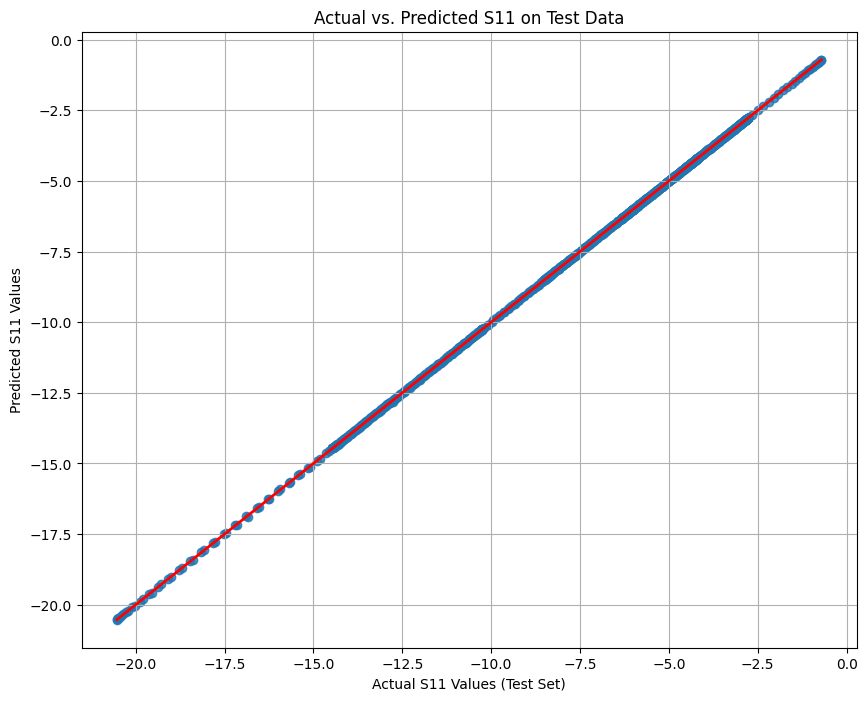

In [3]:
# Step 1: Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Step 2: Load the datasets from your CSV files
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
try:
    # Use pandas to read the CSV files into DataFrames
    train_df = pd.read_csv('training_data.csv')
    test_df = pd.read_csv('testing_data.csv')
    predict_df = pd.read_csv('prediction_data.csv')
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("\nPlease make sure 'training_data.csv', 'testing_data.csv', and 'prediction_data.csv' are in the same directory as this script.")
    exit()

print("--- Data Loaded Successfully ---")
print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)
print("Prediction data shape:", predict_df.shape)
print("\n")


# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Step 3: Prepare the data for modeling
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

# Define the feature columns and the target column
# Features are the inputs to the model.
# Target is the value we want to predict.
features = ['Frequency', 'Ws', 'H1', 'D1', 'Lp', 'W1']
target = 'S11'

# Separate features (X) and target (y) for training and testing sets
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# The prediction set only has features
X_predict = predict_df[features]


# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Step 4: Feature Scaling
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# It's good practice to scale features so they have a similar range.
# This helps many ML models perform better.

# Create a scaler object
scaler = StandardScaler()

# Fit the scaler ONLY on the training data to learn the scaling parameters
scaler.fit(X_train)

# Apply the learned scaling to all three datasets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_predict_scaled = scaler.transform(X_predict)

print("--- Data Preprocessing Complete ---")
print("Features have been scaled.\n")


# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Step 5: Initialize and Train the Machine Learning Model
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

# Initialize the RandomForestRegressor model
# n_estimators: number of trees in the forest.
# random_state: ensures that we get the same results every time we run the code.
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model using the scaled training data
print("--- Training the Model ---")
model.fit(X_train_scaled, y_train)
print("Model training complete.\n")


# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Step 6: Evaluate the Model on the Test Set
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

# Use the trained model to make predictions on the unseen test data
y_pred_test = model.predict(X_test_scaled)

# Calculate performance metrics
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print("--- Model Evaluation on Test Data ---")
print(f"R-squared (R²) Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}\n")

# An R² score close to 1.0 means the model is performing very well.


# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Step 7: Make Predictions on the New Data
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

print("--- Making Final Predictions ---")
# Use the final trained model to predict S11 for the prediction_data.csv
final_predictions = model.predict(X_predict_scaled)

# Add the predictions as a new column to the prediction DataFrame
results_df = predict_df.copy()
results_df['Predicted_S11'] = final_predictions

# Display the first few rows of the results
print("Preview of the predictions:")
print(results_df.head())
print("\n")

# Save the results to a new CSV file
results_df.to_csv('predictions_output.csv', index=False)
print("Predictions saved to 'predictions_output.csv'")


# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# (Optional) Step 8: Visualize the Test Set Performance
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---

plt.figure(figsize=(10, 8))
sns.regplot(x=y_test, y=y_pred_test, line_kws={"color": "red", "lw": 2})
plt.xlabel("Actual S11 Values (Test Set)")
plt.ylabel("Predicted S11 Values")
plt.title("Actual vs. Predicted S11 on Test Data")
plt.grid(True)
plt.show()

In [4]:
import joblib

# Save the trained model to a file
model_filename = 'trained_random_forest_model.joblib'
joblib.dump(model, model_filename)

print(f"Trained model saved to '{model_filename}'")

Trained model saved to 'trained_random_forest_model.joblib'
